In [ ]:
import torch

In [ ]:
##  Tensor is the updatae version of numpy

In [ ]:
import torch # imports the torch module

torch.__version__ # gets the version of the torch module

'2.4.0+cu121'

In [ ]:
import numpy as np

In [ ]:
lst = [3, 4, 5, 6]
arr = np.array(lst)

In [ ]:
# Converting Numpy to Pytorch Tensors
tensors = torch.from_numpy(arr)
tensors

tensor([3, 4, 5, 6])

In [ ]:
tensors.type()

'torch.LongTensor'

In [ ]:
tensors[3]= 56

In [ ]:
tensors

tensor([ 3,  4,  5, 56])

In [ ]:
# to prevent changes to parent file we use torch.tensor
tensor_arr = torch.tensor(arr)
tensor_arr

tensor([ 3,  4,  5, 56])

In [ ]:
tensor_arr[3] = 20
print(tensor_arr)
print(arr)

tensor([ 3,  4,  5, 20])
[ 3  4  5 56]


In [ ]:
# Zeros and ones
torch.ones(2,3, dtype = torch.float64 )

tensor([[1., 1., 1.],
        [1., 1., 1.]], dtype=torch.float64)

In [ ]:
a = torch.tensor([3,4,5], dtype = torch.float)
b = torch.tensor([4, 5, 6], dtype = torch.float)

In [ ]:
torch.add(a, b)

tensor([ 7.,  9., 11.])

In [ ]:
c = torch.zeros(3)
c

tensor([0., 0., 0.])

In [ ]:
torch.add(a, b, out = c).sum()


tensor(27.)

In [ ]:
## Dot product use for the matrix multiplications
## numpy used for traditional operation for huge amount of the
# Multiplications we used tensors
# tensor is the replacement of the numpy to used the power of GPU
a.mul(b).sum()

tensor(62.)

In [ ]:
a.dot(b)

tensor(62.)

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Main

In [ ]:
# Dataset class
class BuildingDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels = [label - 1 for label in labels]  # Convert labels to zero-indexed
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:

# Data transformation with additional augmentations
transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=20, translate=(0.2, 0.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load data
def load_data(train_folder, test_folder):
    classes = ['A', 'B', 'C', 'D', 'S']
    label_map = {cls: idx + 1 for idx, cls in enumerate(classes)}

    img_paths = []
    labels = []

    for cls in classes:
        cls_folder = os.path.join(train_folder, cls)
        for img_name in os.listdir(cls_folder):
            if img_name.endswith('.jpg'):
                img_paths.append(os.path.join(cls_folder, img_name))
                labels.append(label_map[cls])

    train_paths, val_paths, train_labels, val_labels = train_test_split(
        img_paths, labels, test_size=0.2, random_state=42, stratify=labels)

    train_dataset = BuildingDataset(train_paths, train_labels, transform=transform)
    val_dataset = BuildingDataset(val_paths, val_labels, transform=transform)

    return train_dataset, val_dataset

In [ ]:
# Classifier using EfficientNet-B5
class BuildingClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super(BuildingClassifier, self).__init__()
        self.model = models.efficientnet_b5(pretrained=True)  # Using EfficientNet-B5
        num_features = self.model.classifier[1].in_features  # Access the final Linear layer's in_features
        self.model.classifier[1] = nn.Linear(num_features, num_classes)  # Modify the last layer for 5 classes

    def forward(self, x):
        return self.model(x)

In [ ]:

# Early stopping class
class EarlyStopping:
    def __init__(self, patience=10, delta=0.01):  # Increased patience
        self.patience = patience
        self.delta = delta
        self.best_loss = float('inf')
        self.wait = 0
        self.stopped_epoch = 0

    def __call__(self, val_loss, epoch):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                return True
        return False

In [ ]:


# Compute loss and accuracy
def compute_loss_and_accuracy(model, data_loader, device):
    criterion = nn.CrossEntropyLoss()
    model.eval()
    running_loss = 0.0
    corrects = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            corrects += (preds == labels).sum().item()

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_acc = corrects / total
    return epoch_loss, epoch_acc

# Plot confusion matrix
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(5,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# Evaluate model
def evaluate_model(model, val_loader, device):
    val_loss, val_acc = compute_loss_and_accuracy(model, val_loader, device)
    all_labels = []
    all_preds = []
    model.eval()
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(cm, classes=['A', 'B', 'C', 'D', 'S'])

    print(classification_report(all_labels, all_preds, target_names=['A', 'B', 'C', 'D', 'S']))

    return val_loss, val_acc

# Training function
def train_model(model, train_loader, val_loader, num_epochs=50, learning_rate=0.0001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)
    early_stopping = EarlyStopping(patience=10, delta=0.01)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        corrects = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            corrects += (preds == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = corrects / total

        print(f'Epoch {epoch + 1}/{num_epochs}')
        print(f' - Training Loss: {epoch_loss:.4f}')
        print(f' - Training Accuracy: {epoch_acc:.4f}')

        val_loss, val_acc = evaluate_model(model, val_loader, device)
        print(f' - Validation Loss: {val_loss:.4f}')
        print(f' - Validation Accuracy: {val_acc:.4f}')

        scheduler.step(val_loss)

        if early_stopping(val_loss, epoch):
            print(f'Early stopping at epoch {epoch + 1}')
            break




In [ ]:
# Predict and save results
def predict_and_save(model, test_folder, output_file):
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    test_paths = [os.path.join(test_folder, img_name) for img_name in os.listdir(test_folder) if img_name.endswith('.jpg')]
    img_ids = [os.path.basename(path).split('.')[0] for path in test_paths]  # Extract image IDs without extension
    test_dataset = BuildingDataset(test_paths, [0] * len(test_paths), transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    predictions = []
    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            predictions.extend(preds.cpu().numpy() + 1)  # Convert back to 1-indexed

    submission_df = pd.DataFrame({'ID': img_ids, 'Predictions': predictions})
    submission_df.to_csv(output_file, index=False)


In [ ]:
test_paths='/content/unzipped_files/Project 1 Data/Test_Data/10.jpg'
BuildingDataset(test_paths, [0] * len(test_paths), transform=transform)

In [ ]:
import zipfile
import os

# Path to the zip file
zip_file_path = "/content/drive/MyDrive/Datasets/Project 1 Data.zip"

# Directory to extract files to
extract_dir = "/content/unzipped_files/"

# Unzipping the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)


# Optional: Check the files
os.listdir(extract_dir)


['Project 1 Data', '__MACOSX']

Downloading: "https://download.pytorch.org/models/efficientnet_b5_lukemelas-1a07897c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b5_lukemelas-1a07897c.pth
100%|██████████| 117M/117M [00:00<00:00, 134MB/s]


Epoch 1/15
 - Training Loss: 1.3959
 - Training Accuracy: 0.4180


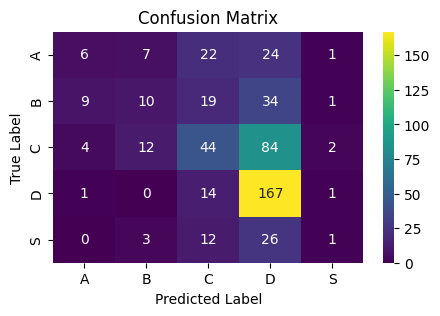

              precision    recall  f1-score   support

           A       0.30      0.10      0.15        60
           B       0.31      0.14      0.19        73
           C       0.40      0.30      0.34       146
           D       0.50      0.91      0.64       183
           S       0.17      0.02      0.04        42

    accuracy                           0.45       504
   macro avg       0.33      0.29      0.27       504
weighted avg       0.39      0.45      0.38       504

 - Validation Loss: 1.4677
 - Validation Accuracy: 0.4921
Epoch 2/15
 - Training Loss: 1.2741
 - Training Accuracy: 0.4707


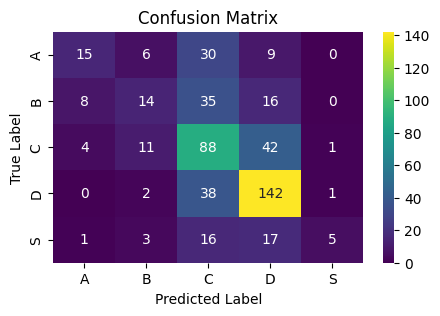

              precision    recall  f1-score   support

           A       0.54      0.25      0.34        60
           B       0.39      0.19      0.26        73
           C       0.43      0.60      0.50       146
           D       0.63      0.78      0.69       183
           S       0.71      0.12      0.20        42

    accuracy                           0.52       504
   macro avg       0.54      0.39      0.40       504
weighted avg       0.53      0.52      0.49       504

 - Validation Loss: 1.3316
 - Validation Accuracy: 0.5159
Epoch 3/15
 - Training Loss: 1.2322
 - Training Accuracy: 0.5070


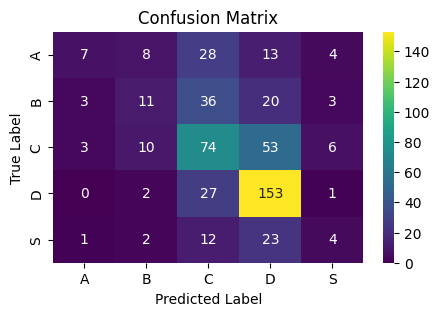

              precision    recall  f1-score   support

           A       0.50      0.12      0.19        60
           B       0.33      0.15      0.21        73
           C       0.42      0.51      0.46       146
           D       0.58      0.84      0.69       183
           S       0.22      0.10      0.13        42

    accuracy                           0.49       504
   macro avg       0.41      0.34      0.34       504
weighted avg       0.46      0.49      0.45       504

 - Validation Loss: 1.3033
 - Validation Accuracy: 0.4563
Epoch 4/15
 - Training Loss: 1.1921
 - Training Accuracy: 0.5403


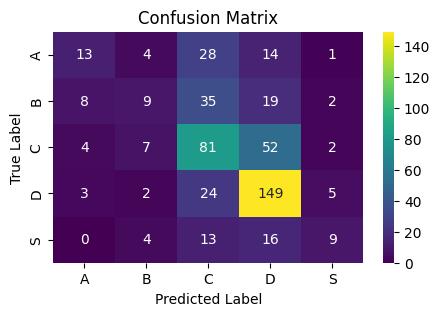

              precision    recall  f1-score   support

           A       0.46      0.22      0.30        60
           B       0.35      0.12      0.18        73
           C       0.45      0.55      0.50       146
           D       0.60      0.81      0.69       183
           S       0.47      0.21      0.30        42

    accuracy                           0.52       504
   macro avg       0.47      0.38      0.39       504
weighted avg       0.49      0.52      0.48       504

 - Validation Loss: 1.2299
 - Validation Accuracy: 0.5198
Epoch 5/15
 - Training Loss: 1.1845
 - Training Accuracy: 0.5258


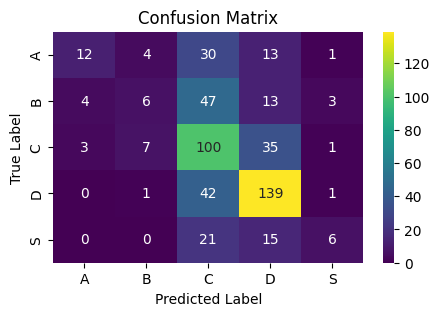

              precision    recall  f1-score   support

           A       0.63      0.20      0.30        60
           B       0.33      0.08      0.13        73
           C       0.42      0.68      0.52       146
           D       0.65      0.76      0.70       183
           S       0.50      0.14      0.22        42

    accuracy                           0.52       504
   macro avg       0.51      0.37      0.37       504
weighted avg       0.52      0.52      0.48       504

 - Validation Loss: 1.2737
 - Validation Accuracy: 0.5179
Epoch 6/15
 - Training Loss: 1.1581
 - Training Accuracy: 0.5422


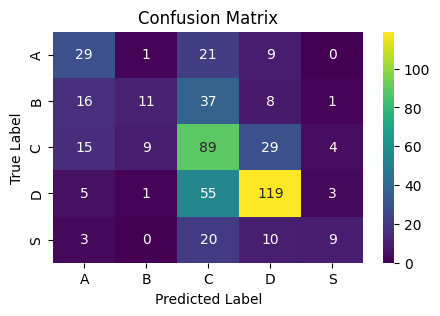

              precision    recall  f1-score   support

           A       0.43      0.48      0.45        60
           B       0.50      0.15      0.23        73
           C       0.40      0.61      0.48       146
           D       0.68      0.65      0.66       183
           S       0.53      0.21      0.31        42

    accuracy                           0.51       504
   macro avg       0.51      0.42      0.43       504
weighted avg       0.53      0.51      0.49       504

 - Validation Loss: 1.2678
 - Validation Accuracy: 0.5079
Epoch 7/15
 - Training Loss: 1.1175
 - Training Accuracy: 0.5641


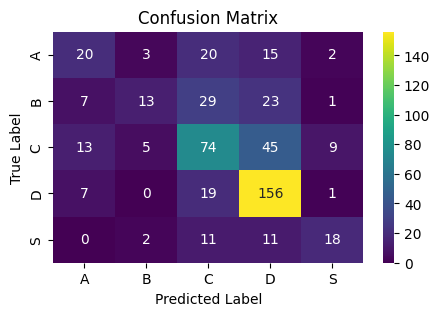

              precision    recall  f1-score   support

           A       0.43      0.33      0.37        60
           B       0.57      0.18      0.27        73
           C       0.48      0.51      0.49       146
           D       0.62      0.85      0.72       183
           S       0.58      0.43      0.49        42

    accuracy                           0.56       504
   macro avg       0.54      0.46      0.47       504
weighted avg       0.55      0.56      0.53       504

 - Validation Loss: 1.2312
 - Validation Accuracy: 0.5298
Epoch 8/15
 - Training Loss: 1.1078
 - Training Accuracy: 0.5676


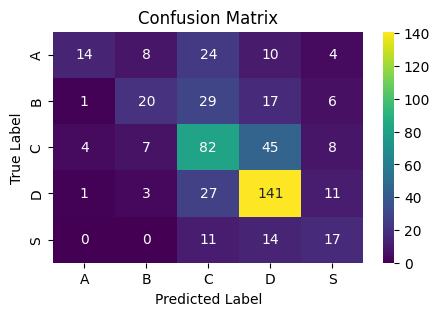

              precision    recall  f1-score   support

           A       0.70      0.23      0.35        60
           B       0.53      0.27      0.36        73
           C       0.47      0.56      0.51       146
           D       0.62      0.77      0.69       183
           S       0.37      0.40      0.39        42

    accuracy                           0.54       504
   macro avg       0.54      0.45      0.46       504
weighted avg       0.55      0.54      0.52       504

 - Validation Loss: 1.3212
 - Validation Accuracy: 0.5139
Epoch 9/15
 - Training Loss: 1.0796
 - Training Accuracy: 0.5800


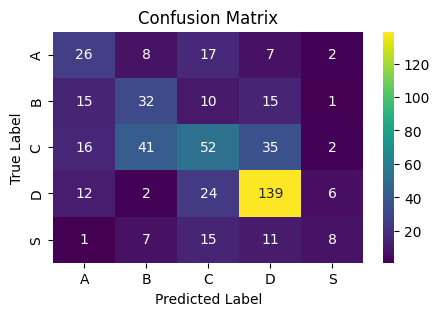

              precision    recall  f1-score   support

           A       0.37      0.43      0.40        60
           B       0.36      0.44      0.39        73
           C       0.44      0.36      0.39       146
           D       0.67      0.76      0.71       183
           S       0.42      0.19      0.26        42

    accuracy                           0.51       504
   macro avg       0.45      0.44      0.43       504
weighted avg       0.50      0.51      0.50       504

 - Validation Loss: 1.3422
 - Validation Accuracy: 0.5238
Epoch 10/15
 - Training Loss: 1.1045
 - Training Accuracy: 0.5815


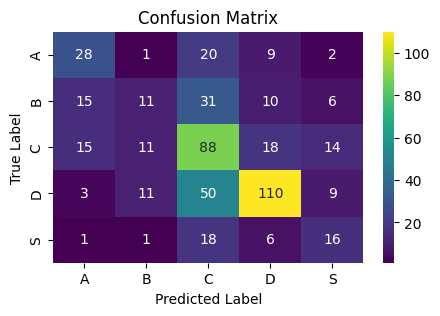

              precision    recall  f1-score   support

           A       0.45      0.47      0.46        60
           B       0.31      0.15      0.20        73
           C       0.43      0.60      0.50       146
           D       0.72      0.60      0.65       183
           S       0.34      0.38      0.36        42

    accuracy                           0.50       504
   macro avg       0.45      0.44      0.44       504
weighted avg       0.51      0.50      0.50       504

 - Validation Loss: 1.2897
 - Validation Accuracy: 0.5198


In [ ]:
# File paths
train_folder = '/content/unzipped_files/Project 1 Data/Train_Data'
test_folder = '/content/unzipped_files/Project 1 Data/Test_Data'
output_file = '/content/submission_efficientnet_b5.csv'

# Load data and create data loaders
train_dataset, val_dataset = load_data(train_folder, test_folder)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Initialize and train model
model = BuildingClassifier(num_classes=5)
train_model(model, train_loader, val_loader, num_epochs=15, learning_rate=0.0005)

# Predict and save results
predict_and_save(model, test_folder, output_file)